Test the algorithm with and without warm up sampling a 5D Gaussian with mena zero and variance 1 on each diemnsion.

In [17]:
import arviz as az
import numpy as np
from scipy.stats import wishart
import matplotlib.pyplot as plt
import math

# Set random seed for reproducibility (same seed of Mattia's 250D notebook)
rng = np.random.default_rng(12345)

# Utils

In [18]:
def chain_stats(samples):
    mean = samples.mean(axis=0)
    std  = samples.std(axis=0)
    return mean, std

def autocorr(x):
    x = x - x.mean()
    n = x.shape[0]
    f = jnp.fft.fft(x, n=2*n)
    acf = jnp.fft.ifft(f * jnp.conj(f))[:n].real
    acf = acf / acf[0]
    return acf

def autocorr_functional(x):
    x = x - np.mean(x)
    N = len(x)
    var = np.var(x)

    acf = np.zeros(N)
    for s in range(N):
        acf[s] = np.dot(x[:N-s], x[s:]) / ((N - s) * var)
    return acf

def print_trajectory(samples, dim=0, n=20):
    print("Traiettoria dimensione", dim)
    print(samples[:n, dim])
    
def print_distribution(samples):
    mean, std = chain_stats(samples)
    print("Mean:", mean)
    print("Std:", std)

def check_gaussian(samples):
    mean, std = chain_stats(samples)
    print("-------check_gaussian--------")
    print("Target mean = 0")
    print("Empirical mean =", mean)
    print("Target std = 1")
    print("Empirical std =", std)
    print("-----------------------------")

# Test simple sampler

Sample the default Gaussian distribution with 5 dimensions:

In [19]:
# Define the pseudo log-potential
# Gaussian log-density
def L(theta):
    return -0.5 * jnp.vdot(theta, theta)

In [20]:
# JAX automatic differentiation
#grad_L = jax.grad(L)
logprob_and_grad = jax.value_and_grad(L)

In [21]:
# versione jittata
nuts_sampler_jit = jax.jit(nuts_sampler, static_argnums=(1,))


In [22]:
key = jrnd.PRNGKey(0)
D=5
theta0 = jnp.zeros(D)

samples, eps = nuts_sampler_jit(theta0, 1000, key)

print("epsilon:", eps)

print_distribution(samples)
check_gaussian(samples)

print_trajectory(samples, dim=0, n=20)

epsilon trovato: 0.5
Mean: [-0.03367876 -0.05043489 -0.00348981 -0.02949037  0.05628461]
Std: [1.0167265 1.0465059 1.0708578 1.0136257 1.050112 ]
-------check_gaussian--------
Target mean = 0
Empirical mean = [-0.03367876 -0.05043489 -0.00348981 -0.02949037  0.05628461]
Target std = 1
Empirical std = [1.0167265 1.0465059 1.0708578 1.0136257 1.050112 ]
-----------------------------
Traiettoria dimensione 0
[ 1.4549787   1.4549787   1.1470665   0.7064935   0.08950061 -1.6468093
  1.1282353   1.1282353  -1.1541804  -0.43310684  1.8850311  -1.025902
 -1.025902   -1.025902    0.32332015 -0.5703143  -0.95990276 -1.1580303
 -1.0324098   0.9727786 ]


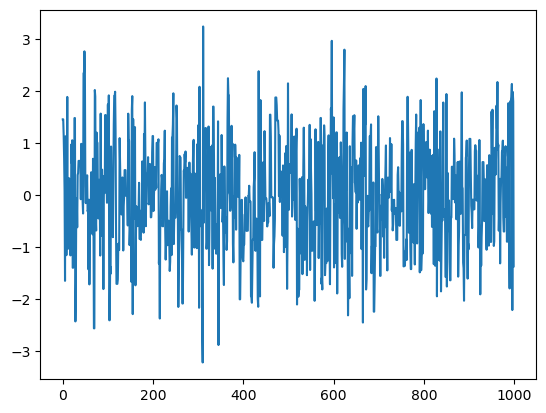

In [23]:
plt.plot(samples[:,0])

array([[<Axes: ylabel='theta\n0'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: ylabel='theta\n1'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: ylabel='theta\n2'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: ylabel='theta\n3'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: xlabel='theta\n0', ylabel='theta\n4'>,
        <Axes: xlabel='theta\n1'>, <Axes: xlabel='theta\n2'>,
        <Axes: xlabel='theta\n3'>, <Axes: xlabel='theta\n4'>]],
      dtype=object)

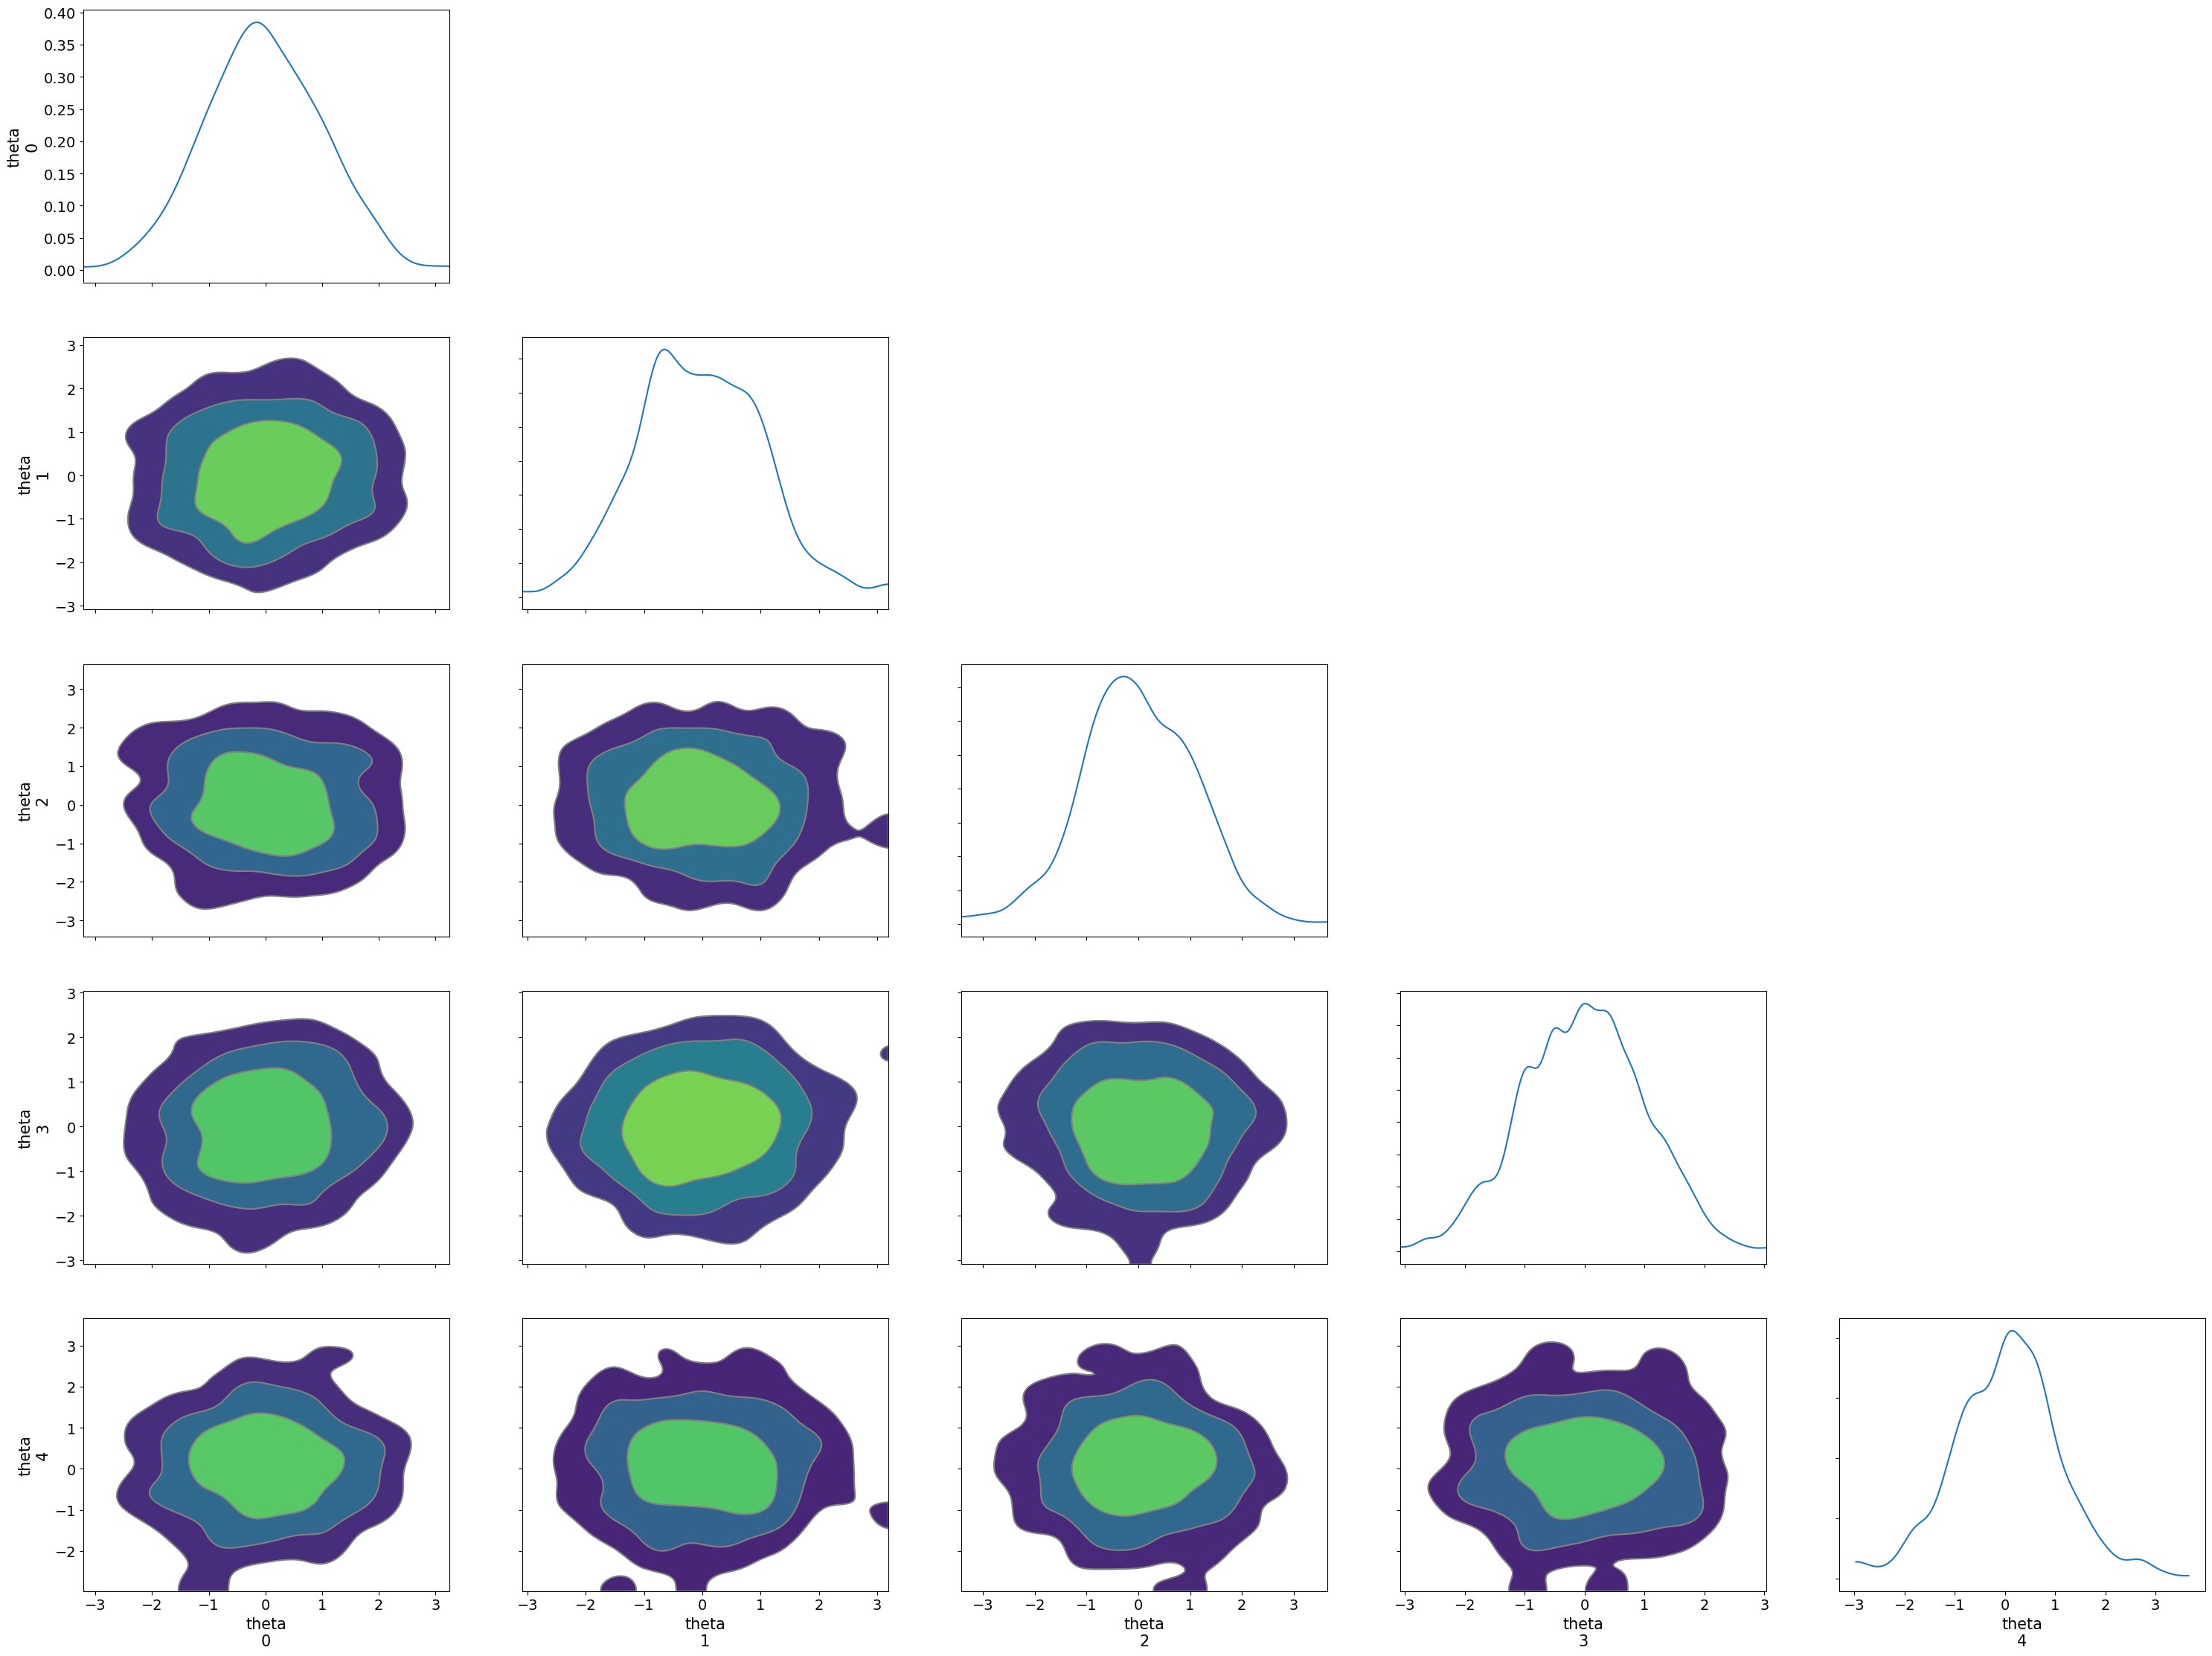

In [24]:
# add a pseudo dimension to plot the data
samples = samples[None, :, :]   # shape diventa (1, 1000, 10)

# plot the sampled data marginalized distributions
idata = az.from_dict(
    posterior={"theta": samples},
    coords={"theta_dim": np.arange(samples.shape[-1])},
    dims={"theta": ["chain", "draw", "theta_dim"]},
)

az.plot_pair(idata, var_names=["theta"], kind="kde", marginals=True)

# NUTS + Warm up

In [29]:
NUTS_sampler_wu_jit = jax.jit(NUTS_sampler_wu, static_argnums=(1,2))

In [34]:
key = jrnd.PRNGKey(0)
D=5
theta0 = jnp.zeros(D)

warmup_cfg = WarmupConfig(
    num_warmup=1000,
    delta=0.8,
    adapt_mass=False,   
)


samples, epsilon_final = NUTS_sampler_wu_jit(
    theta0=theta0,
    num_warmup=1000,
    num_samples=1000,
    key=key,
    warmup_cfg=warmup_cfg,
    j_max=10
)

print("epsilon after the warmup:", epsilon_final)

print_distribution(samples)
check_gaussian(samples)

print_trajectory(samples, dim=0, n=20)

epsilon after the warmup: 1.00538
Mean: [-0.06971989  0.01024871  0.00561761 -0.00933535 -0.03886529]
Std: [1.0067512 1.0351317 1.0290041 1.0084265 1.0715863]
-------check_gaussian--------
Target mean = 0
Empirical mean = [-0.06971989  0.01024871  0.00561761 -0.00933535 -0.03886529]
Target std = 1
Empirical std = [1.0067512 1.0351317 1.0290041 1.0084265 1.0715863]
-----------------------------
Traiettoria dimensione 0
[ 1.5157268   1.5157268   1.5157268   1.5157268   1.0516876   1.0516876
  1.0516876   1.0516876   0.9049573  -0.65390486 -1.035611    1.0068102
  1.0068102   0.3226223   0.3226223  -0.6148893  -0.6148893  -0.38549384
 -0.38549384  0.10959911]


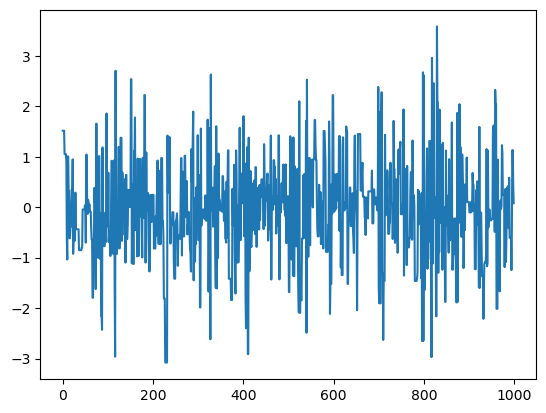

In [32]:
plt.plot(samples[:,0])

array([[<Axes: ylabel='theta\n0'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: ylabel='theta\n1'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: ylabel='theta\n2'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: ylabel='theta\n3'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: xlabel='theta\n0', ylabel='theta\n4'>,
        <Axes: xlabel='theta\n1'>, <Axes: xlabel='theta\n2'>,
        <Axes: xlabel='theta\n3'>, <Axes: xlabel='theta\n4'>]],
      dtype=object)

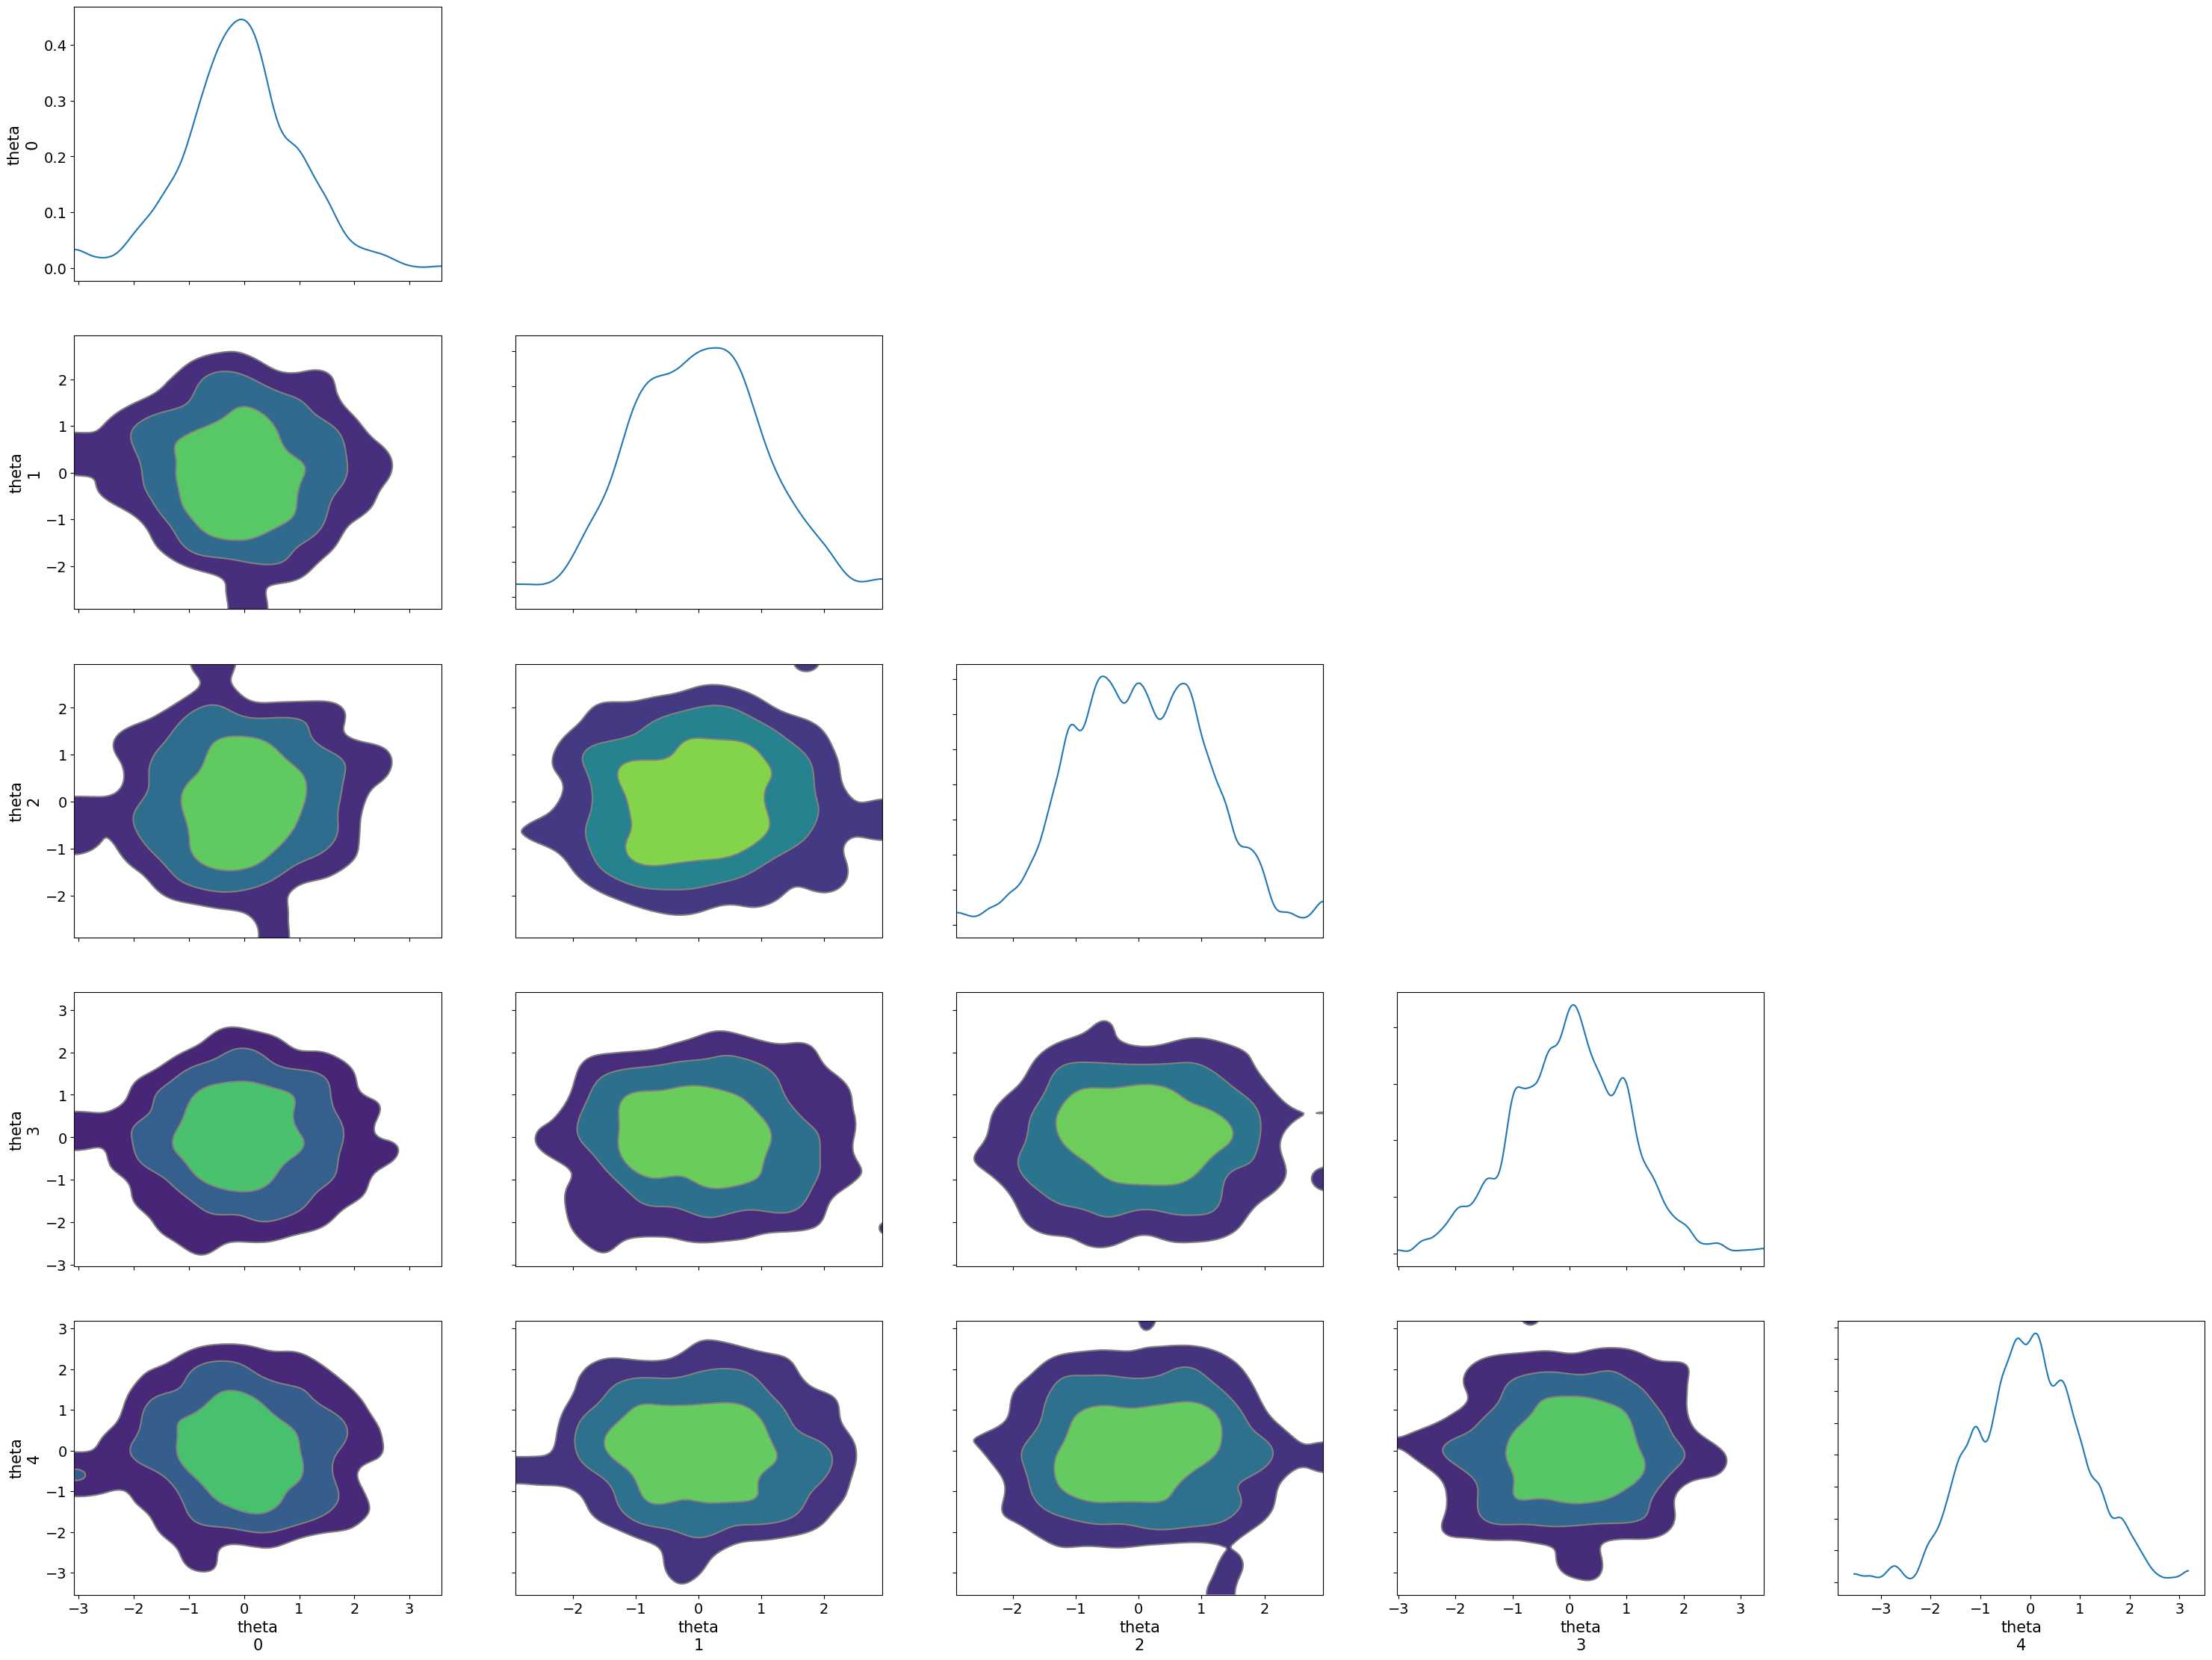

In [33]:
# add a pseudo dimension to plot the data
samples = samples[None, :, :]   # shape diventa (1, 1000, 10)

# plot the sampled data marginalized distributions
idata = az.from_dict(
    posterior={"theta": samples},
    coords={"theta_dim": np.arange(samples.shape[-1])},
    dims={"theta": ["chain", "draw", "theta_dim"]},
)

az.plot_pair(idata, var_names=["theta"], kind="kde", marginals=True)